In [ ]:
import torch 
from torchvision.datasets import CIFAR10
from torchvision import transforms

# Dataset 

In [94]:
train_data =  CIFAR10(root="/tmp/cifar10",train=True,download=True)
train_data

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: /tmp/cifar10
    Split: Train

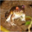

In [ ]:
x,y = train_data[0]
x # PIL (Python Image library | the modern one is Pillow )

In [96]:
print(x)
print(y)

<PIL.Image.Image image mode=RGB size=32x32 at 0x1384D3DD0>
6


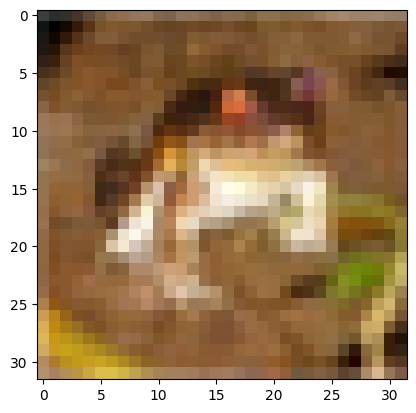

In [97]:
import matplotlib.pyplot as plt 

plt.imshow(x)

# Transformations 

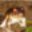

In [101]:
transforms.RandomResizedCrop(size=32,scale=(0.08,1))(x)

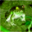

In [ ]:
transforms.ColorJitter(brightness=0.4,contrast=0.4,saturation=0.2,hue=0.2)(x)

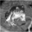

In [99]:
transforms.Grayscale(num_output_channels=3)(x)

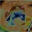

In [102]:
transforms.functional.solarize(x,threshold=128)

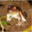

In [103]:
transforms.functional.hflip(x)

In [106]:
transforms.ToTensor()(x)    # Torch image aka. [C,H,W]

tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
         [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
         [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
         ...,
         [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
         [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
         [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],

        [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
         [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
         [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
         ...,
         [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
         [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
         [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],

        [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
         [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],
         [0.0824, 0.0000, 0.0314,  ..., 0.1961, 0.1961, 0.

The argument for `transforms.Normalize` must be Torch Image 

In [108]:
transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))(transforms.ToTensor()(x))

tensor([[[-1.2854e+00, -1.5955e+00, -1.4598e+00,  ...,  6.3375e-01,
           5.1744e-01,  4.3990e-01],
         [-2.1189e+00, -2.4291e+00, -2.0801e+00,  ..., -4.4721e-02,
          -1.2226e-01, -6.4106e-02],
         [-1.9444e+00, -2.1189e+00, -1.4792e+00,  ..., -1.4165e-01,
          -1.0288e-01, -3.1611e-01],
         ...,
         [ 1.6030e+00,  1.4673e+00,  1.4091e+00,  ...,  6.7252e-01,
          -1.3435e+00, -1.4017e+00],
         [ 1.0602e+00,  9.2452e-01,  1.1765e+00,  ...,  1.1378e+00,
          -5.4873e-01, -8.2012e-01],
         [ 1.0021e+00,  8.2760e-01,  1.0408e+00,  ...,  1.7581e+00,
           4.9806e-01, -4.4721e-02]],

        [[-1.1989e+00, -1.5136e+00, -1.4742e+00,  ...,  1.7777e-01,
           4.0101e-02,  2.0434e-02],
         [-2.0249e+00, -2.4183e+00, -2.2609e+00,  ..., -6.8757e-01,
          -7.8591e-01, -7.0724e-01],
         [-1.9463e+00, -2.2806e+00, -1.8873e+00,  ..., -7.6624e-01,
          -7.6624e-01, -9.8258e-01],
         ...,
         [ 9.2511e-01,  5

How `transforms.Compose` ~ work behind the scene. 

In [15]:
# essentailly under the hood 

# class Compose:
#     def __init__(self, transforms):
#         self.transforms = transforms

#     def __call__(self, img):
#         for t in self.transforms:
#             img = t(img)
#         return img

# Wrap the tansformation inside a class, but why ? 

It makes the codebase look uniform and makes it easier to extend later (e.g., adding logging, conditional logic, or extra parameters).

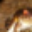

In [111]:
class RandomResizedCrop: 
    def __init__(self,size,scale=(0.2,1.0)): 
        self.size = size 
        self.scale  = scale 

    def __call__(self,img): 
        return transforms.RandomResizedCrop(self.size,self.scale)(img)

RandomResizedCrop(32)(x)

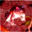

In [112]:
class ColorJitter: 
    def __init__(self,brightness=0.4,contrast=0.4,saturation=0.2,hue=0.2):
        self.transform = transforms.ColorJitter(brightness,contrast,saturation,hue)

    def __call__(self,img):
        return self.transform(img)

ColorJitter()(x)

In [ ]:
class GrayScale: 
    def __init__(self,prob=0.2): 
        self.prob = prob 

    def __call__(self,img): 
        if torch.rand(1) < self.prob : 
            return transforms.Grayscale(num_output_channels=3)(x)
        return img 

GrayScale()(x)

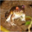

In [114]:
class Solarization: 
    def __init__(self,prob=0.1): 
        self.prob = prob

    def __call__(self,img): 
        if torch.rand(1) < self.prob:
            return transforms.functional(img,threshold=128)
        return img 

Solarization()(x)

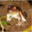

In [121]:
class HorizontalFlip: 
    def __init__(self,prob=0.5): 
        self.prob = prob

    def __call__(self,img):
        if torch.rand(1) < self.prob : 
            return transforms.functional.hflip(img)
        return img 

HorizontalFlip()(x)

# get_train_transforms

In [16]:
train_data.data.shape

(50000, 32, 32, 3)

In [33]:
torch.mean(torch.tensor(train_data.data / 255.),dim=(0,1,2))
torch.std(torch.tensor(train_data.data / 255.),dim=(0,1,2))

tensor([0.2470, 0.2435, 0.2616], dtype=torch.float64)

In [ ]:
normalization = transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))

In [55]:
normalization(trans_to_tensor(x)).shape

torch.Size([3, 32, 32])

In [ ]:
def get_train_transform(): 
    transform = transforms.Compose(
        [
            transforms.RandomResizedCrop()
        ]
    )